# Tile Coding on Foragers

**De Python:**

In [1]:
import sys

sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from agents.linearQ import TilesQ
from utils.performer import Performer
from utils.plot_utils import PlotQApprox2D
from utils.interpreters import gym_interpreter1
from environments.foragers import DiscreteForagersEnv

In [2]:
num_actions = 11
env = DiscreteForagersEnv(
    initial_rate=0.5,
    initial_wealth=0.5,
    num_foragers=3,
    num_discrete_actions=num_actions
)
state = env.reset()

## Create tile coding for value function

In [3]:
state_scales = [
    {'min':0.0, 'max':1.0},
    {'min':0.0, 'max':1.0},
]
tiles_parameters = {
    'numDims': 2,
    'numTilings': 8,
    'numTiles': [8, 8],
    'scaleFactors':state_scales,
    'maxSize':4096,
    'alpha':0.1,
    'num_actions': num_actions
}
value_approximator = TilesQ(parameters=tiles_parameters)

In [4]:
agent_parameters = {
    'nA':num_actions,
    'nS':2,
    'gamma':0.95,
    'epsilon':0.1,
    'alpha':0.1,
    'Q':value_approximator
}
env_parameters = {
    'num_foragers':3,
    'num_discrete_actions':num_actions,

}
perf = Performer(
    env_name='DiscreteForagersEnv',
    env_parameters=env_parameters,
    state_interpreter=gym_interpreter1,
    agent_name='agentsCS.QLearningCS',
    agent_parameters=agent_parameters
)

In [5]:
perf.run(
    num_rounds=10, 
    visual=False,
    from_file=True,
)

Loading agent from /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/models/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.json

----------Round 0----------

	The state is => [0. 1.]
	Agent takes action => 3
	The state obtained is => [0.3 0.8]
	The reward obtained is => 0.9822222222222222
	Environment is finished? => False
	Environment is truncated? => False

----------Round 1----------

	The state is => [0.3 0.8]
	Agent takes action => 5
	The state obtained is => [0.5 0.8]
	The reward obtained is => 0.9822222222222222
	Environment is finished? => False
	Environment is truncated? => False

----------Round 2----------

	The state is => [0.5 0.8]
	Agent takes action => 7
	The state obtained is => [0.7 0.8]
	The reward obtained is => 0.9822222222222222
	Environment is finished? => False
	Environment is truncated? => False

----------Round 3----------

	The state is => [0.7 0.8]
	Agent takes action => 6
	The state obtained is => [0.6 0.8]
	The reward obtained

  0%|          | 0/1000 [00:00<?, ?it/s]

Data saved to /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/data/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.csv
Agent saved to /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/models/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.json
Plot saved to /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/images/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.png


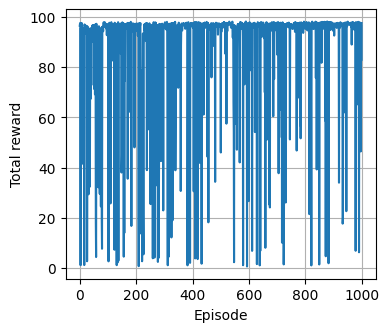

In [6]:
perf.train(
    num_rounds=100, 
    num_episodes=1000,
    from_file=False,
)

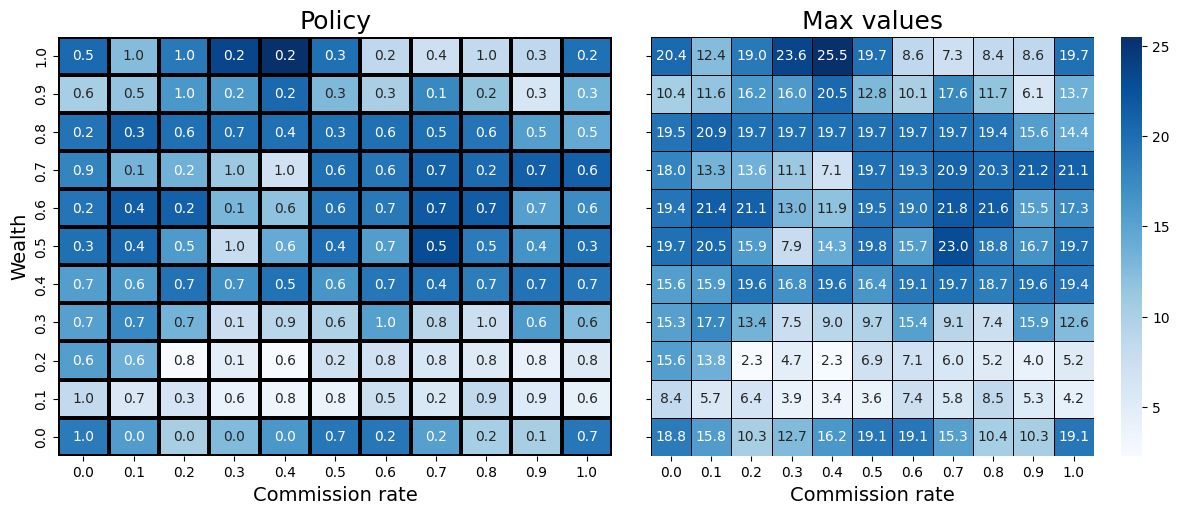

In [7]:
dict_acciones = {i:f"{i/(num_actions - 1):.1f}" for i in range(num_actions)}
q_plot = PlotQApprox2D(
    Q=perf.agent.Q,
    state_scales=state_scales, 
    dict_acciones=dict_acciones,
    mesh_size=num_actions,
)
fig, ax = q_plot.best_actions_with_values(max_deci=1)
fig.shared_axes = True
fig.tight_layout()
ax[0].set_xlabel('Commission rate', fontsize='14')
ax[0].set_ylabel('Wealth', fontsize='14')
ax[1].tick_params(labelleft=False)
ax[1].set_xlabel('Commission rate', fontsize='14')
plt.show()

Rate: 0.00, Wealth: 0.00, Proposed Rate: 1.00
Rate: 0.00, Wealth: 0.10, Proposed Rate: 1.00
Rate: 0.00, Wealth: 0.20, Proposed Rate: 0.60
Rate: 0.00, Wealth: 0.30, Proposed Rate: 0.70
Rate: 0.00, Wealth: 0.40, Proposed Rate: 0.70
Rate: 0.00, Wealth: 0.50, Proposed Rate: 0.30
Rate: 0.00, Wealth: 0.60, Proposed Rate: 0.20
Rate: 0.00, Wealth: 0.70, Proposed Rate: 0.90
Rate: 0.00, Wealth: 0.80, Proposed Rate: 0.20
Rate: 0.00, Wealth: 0.90, Proposed Rate: 0.60
Rate: 0.00, Wealth: 1.00, Proposed Rate: 0.50
Rate: 0.10, Wealth: 0.00, Proposed Rate: 0.00
Rate: 0.10, Wealth: 0.10, Proposed Rate: 0.70
Rate: 0.10, Wealth: 0.20, Proposed Rate: 0.60
Rate: 0.10, Wealth: 0.30, Proposed Rate: 0.70
Rate: 0.10, Wealth: 0.40, Proposed Rate: 0.60
Rate: 0.10, Wealth: 0.50, Proposed Rate: 0.40
Rate: 0.10, Wealth: 0.60, Proposed Rate: 0.40
Rate: 0.10, Wealth: 0.70, Proposed Rate: 0.10
Rate: 0.10, Wealth: 0.80, Proposed Rate: 0.30
Rate: 0.10, Wealth: 0.90, Proposed Rate: 0.50
Rate: 0.10, Wealth: 1.00, Proposed

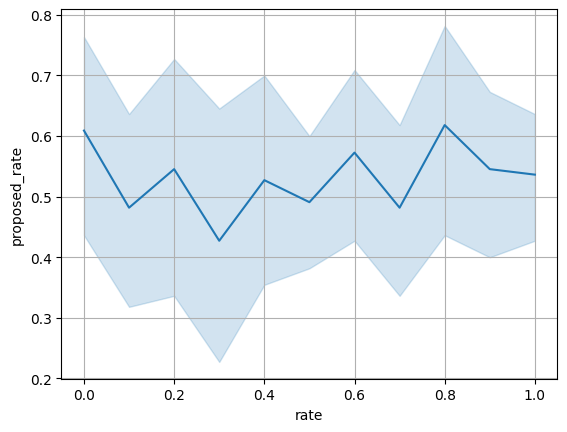

In [8]:
rates, wealths = q_plot.create_mesh()
df = pd.DataFrame({}, columns=['rate', 'wealth', 'proposed_rate'])

for rate in rates:
    for wealth in wealths:
        proposed_rate = perf.agent.argmaxQ([rate, wealth])
        proposed_rate = proposed_rate / (num_actions - 1)  # Convert discrete action to continuous value
        print(f"Rate: {rate:.2f}, Wealth: {wealth:.2f}, Proposed Rate: {proposed_rate:.2f}")
        df.loc[len(df)] = {'rate': rate, 'wealth': wealth, 'proposed_rate': proposed_rate}

ax = sns.lineplot(x='rate', y='proposed_rate', data=df)
ax.grid()


Loading agent from /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/models/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.json


  0%|          | 0/100 [00:00<?, ?it/s]

Data saved to /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/data/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv_test_csv.csv
Average sum of rewards:
 model
QLearningCS    88.168773
Name: reward, dtype: float64

Episode termination percentage:
 model
QLearningCS    13.0
Name: done, dtype: float64
Plot saved to /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/images/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv_test.png


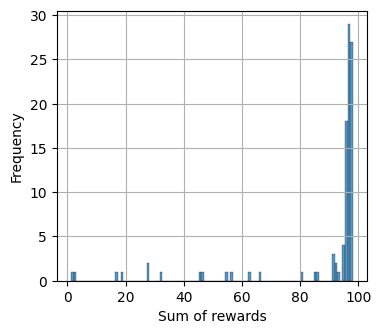

In [9]:
perf.test(num_rounds=100, num_episodes=100)